# Task 2 - Experimentation and Uplift Testing

This notebook is the second part of a retail analytics case study completed as part of the Quantium Virtual Internship program. A supermarket chain trialled a new store layout for its chips category in three stores between February and April 2019, hoping to boost sales, and asked for an assessment of whether the trial worked. This analysis identifies a matched control store for each trial store based on pre-trial performance, then tests whether the trial period showed a statistically significant uplift compared to that control. It follows on from the customer segmentation analysis in Part 1 of this portfolio.

**TL;DR:** All three trial stores saw a significant short-term boost in sales and foot traffic in the first month of the trial, but only store 77 sustained that uplift through the full three months. The effect faded quickly in the other two stores, most likely reflecting a novelty effect rather than a lasting change in shopping behavior.

**Contents**
1. [Load libraries and data](#1-load-libraries-and-data)
2. [Data preparation](#2-data-preparation)
3. [Trial stores and data completeness check](#3-trial-stores-and-data-completeness-check)
4. [Monthly store metrics](#4-monthly-store-metrics)
5. [Control store selection (correlation analysis, pre-trial period)](#5-control-store-selection-correlation-analysis-pre-trial-period)
6. [Trial vs control store comparison over time](#6-trial-vs-control-store-comparison-over-time)
7. [Statistical significance testing](#7-statistical-significance-testing)
8. [Visualizing results with confidence intervals](#8-visualizing-results-with-confidence-intervals)
9. [Store-by-store analysis](#9-store-by-store-analysis)
10. [Conclusion](#10-conclusion)

## 1. Load libraries and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from matplotlib.colors import ListedColormap


In [2]:
data = pd.read_csv('/Users/thibautraiola/DATA-ANALYST/Project4Portfolio/Forage/Quantium - DA /1. Data preparation & customer analytics/Done/cleaned_data.csv')

## 2. Data preparation

In [3]:
data['DATE'] = pd.to_datetime(data['DATE'])
data['MONTH'] = data['DATE'].dt.to_period('M')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248229 entries, 0 to 248228
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              248229 non-null  datetime64[ns]
 1   STORE_NBR         248229 non-null  int64         
 2   LYLTY_CARD_NBR    248229 non-null  int64         
 3   TXN_ID            248229 non-null  int64         
 4   PROD_NBR          248229 non-null  int64         
 5   PROD_NAME         248229 non-null  object        
 6   PROD_QTY          248229 non-null  int64         
 7   TOT_SALES         248229 non-null  float64       
 8   PACK_SIZE         248229 non-null  int64         
 9   BRAND_NAME        248229 non-null  object        
 10  LIFESTAGE         248229 non-null  object        
 11  PREMIUM_CUSTOMER  248229 non-null  object        
 12  MONTH             248229 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(6), object(4), peri

## 3. Trial stores and data completeness check

In [5]:
trial_stores = [77, 86, 88]

Only keep stores with data across all 12 months, so they can be reliably used as control store candidates.

In [6]:
months_per_store = data.groupby('STORE_NBR')['MONTH'].nunique()
incomplete_stores = months_per_store[months_per_store != 12].index

data_complete_stores = data[~data['STORE_NBR'].isin(incomplete_stores)]

## 4. Monthly store metrics

In [7]:
monthly_stats = data_complete_stores.groupby(['STORE_NBR', 'MONTH']).agg(
    total_sales=('TOT_SALES', 'sum'),
    n_transactions=('TXN_ID', 'count'),
    n_customers=('LYLTY_CARD_NBR', 'nunique')
)

monthly_stats['avg_transactions_per_customer'] = round(monthly_stats['n_transactions'] / monthly_stats['n_customers'], 2)

monthly_stats

total_sales  n_transactions  n_customers  \
STORE_NBR MONTH                                               
1         2018-07        191.6              50           48   
          2018-08        168.4              41           41   
          2018-09        268.1              59           57   
          2018-10        178.0              41           40   
          2018-11        187.5              46           45   
...                        ...             ...          ...   
272       2019-02        385.3              47           44   
          2019-03        421.9              51           48   
          2019-04        445.1              56           54   
          2019-05        314.6              40           34   
          2019-06        301.9              36           33   

                   avg_transactions_per_customer  
STORE_NBR MONTH                                   
1         2018-07                           1.04  
          2018-08                           1.00  
          2018-09                           1.04  
          2018-10                           1.02  
          2018-11                           1.02  
...                                          ...  
272       2019-02                           1.07  
          2019-03                           1.06  
          2019-04                           1.04  
          2019-05                           1.18  
          2019-06                           1.09  

[3108 rows x 4 columns]

## 5. Control store selection (correlation analysis, pre-trial period)

In [8]:
monthly_stats_before_trial = monthly_stats[monthly_stats.index.get_level_values('MONTH') < '2019-02']

In [9]:
def get_pivot(metric):
    pivot = monthly_stats_before_trial[metric].unstack('STORE_NBR')
    return pivot

In [10]:
corr_mat_sales = get_pivot('total_sales').corr()
corr_mat_n_cust = get_pivot('n_customers').corr()
corr_mat_avg_txn = get_pivot('avg_transactions_per_customer').corr()

In [11]:
def get_abs_diff(metric, trial_store):
    pivot = get_pivot(metric)
    diff = pivot.sub(pivot[trial_store], axis=0).abs()
    min_diff = diff.min(axis=1)
    max_diff = diff.max(axis=1)
    normalisation = 1 - diff.sub(min_diff, axis=0).div(max_diff - min_diff, axis=0)
    score = normalisation.mean(axis=0)
    return score

def ranking(store_nbr):
    corr_sales = corr_mat_sales[store_nbr]
    corr_n_cust = corr_mat_n_cust[store_nbr]
    corr_avg = corr_mat_avg_txn[store_nbr]
    diff_sales = get_abs_diff('total_sales', store_nbr)
    diff_n_cust = get_abs_diff('n_customers', store_nbr)
    diff_avg = get_abs_diff('avg_transactions_per_customer', store_nbr)
    score = ((corr_sales * 0.5) + (diff_sales * 0.5) + (corr_n_cust * 0.5) + (diff_n_cust * 0.5) + (corr_avg * 0.5) + (diff_avg * 0.5)) / 3 
    final_score = score.drop(store_nbr)
    sorted_score = final_score.sort_values(ascending=False)
    return sorted_score

pairs = {}
for store in trial_stores:
    control_store = ranking(store).index[0]
    pairs[store] = control_store
pairs

{77: np.int64(84), 86: np.int64(138), 88: np.int64(201)}

## 6. Trial vs control store comparison over time

In [12]:
metrics = ['total_sales', 'n_customers', 'avg_transactions_per_customer']

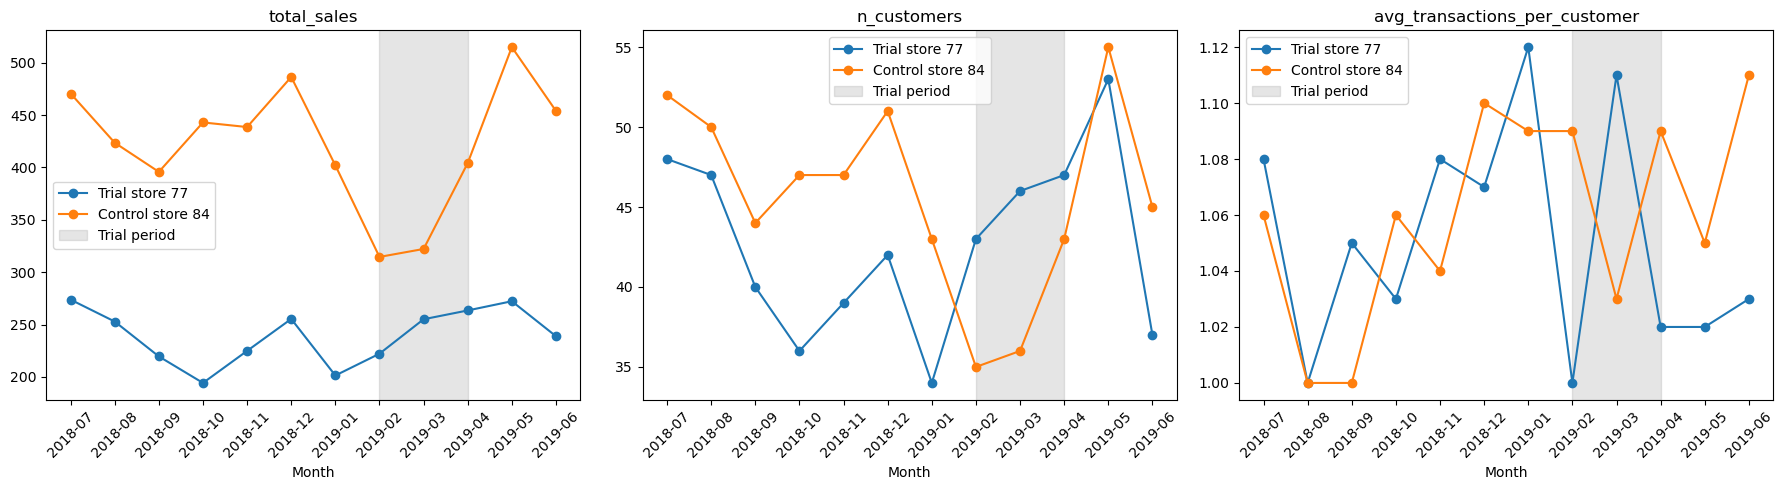

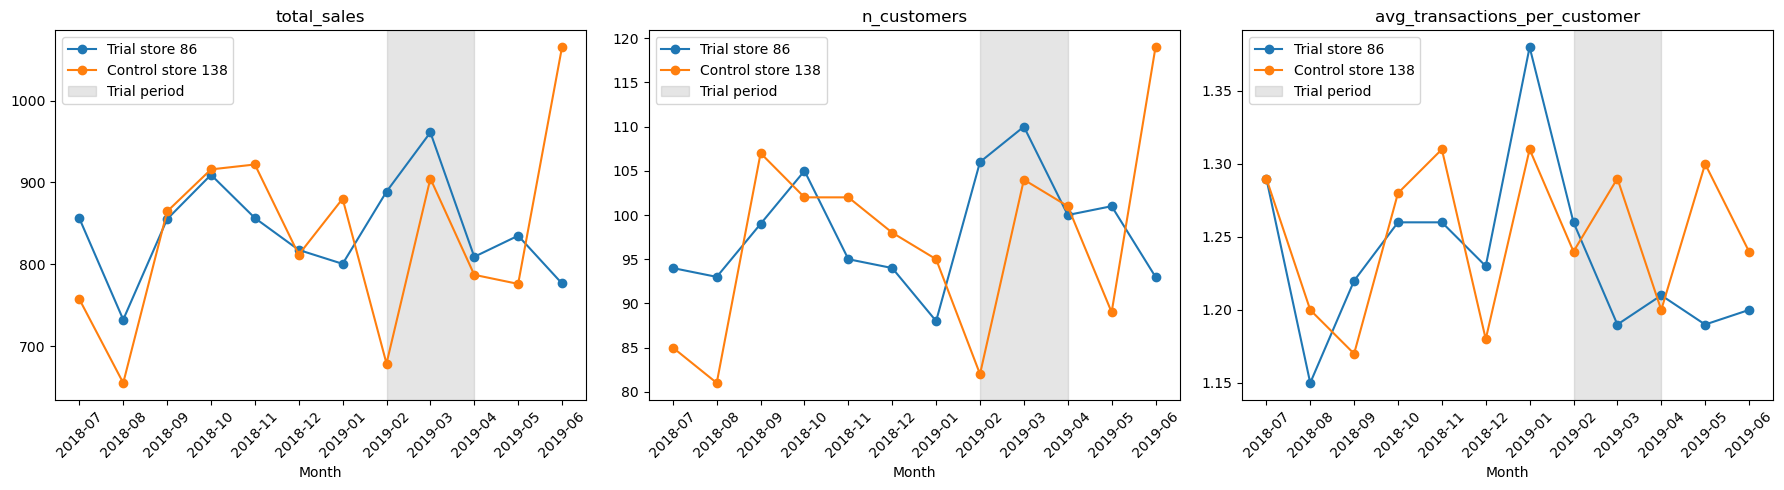

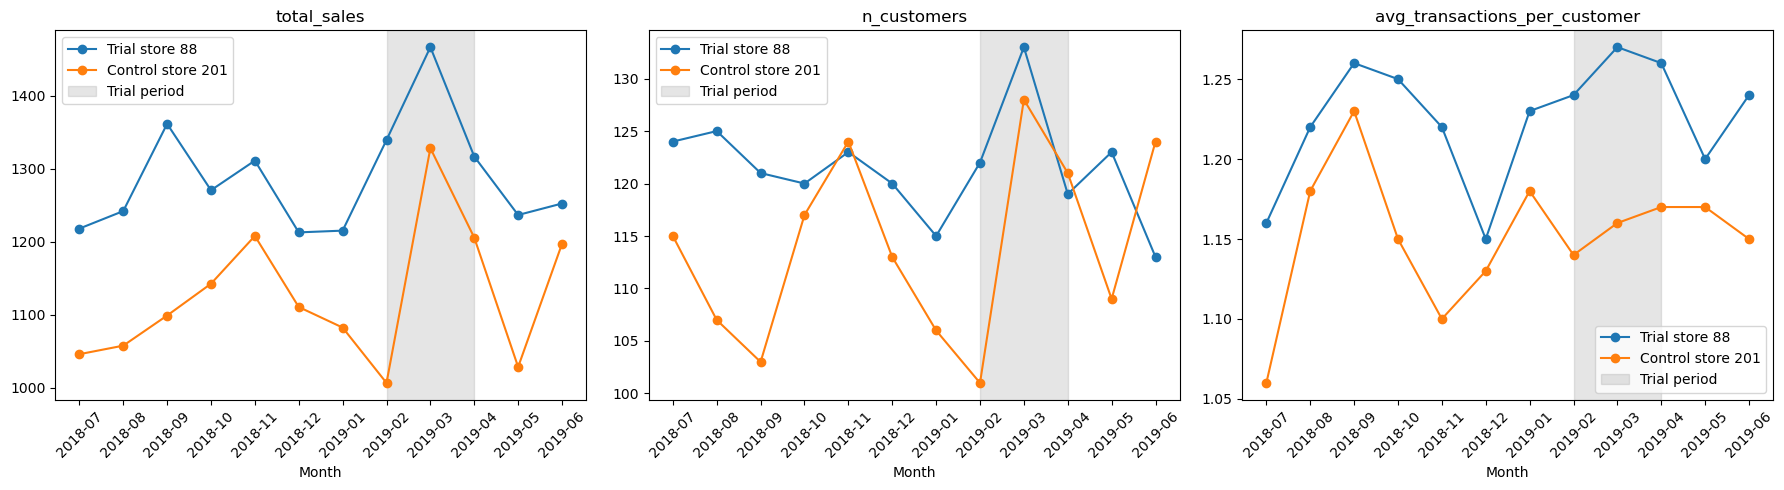

In [13]:
def plot_trial_vs_control_raw(trial_store, control_store):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, metric in zip(axes, metrics):
        trial_data = monthly_stats.loc[trial_store, metric]
        control_data = monthly_stats.loc[control_store, metric]

        ax.plot(trial_data.index.astype(str), trial_data.values, marker='o', label=f'Trial store {trial_store}')
        ax.plot(control_data.index.astype(str), control_data.values, marker='o', label=f'Control store {control_store}')
        ax.axvspan('2019-02', '2019-04', color='grey', alpha=0.2, label='Trial period')
        ax.set_title(metric)
        ax.set_xlabel('Month')
        ax.tick_params(axis='x', rotation=45)
        ax.legend()

    plt.tight_layout()
    plt.show()

for trial_store, control_store in pairs.items():
    plot_trial_vs_control_raw(trial_store, control_store)



The plots above confirm the trial/control pair assignments. Visually, store performance across the three metrics appears reasonably correlated. However, the 77/84 pair shows a scale mismatch: looking at total_sales, the control store records almost twice as much revenue as the trial store. To ensure a valid analysis, store performance will need to be rescaled.

## 7. Statistical significance testing

In [14]:
results = []

for trial, control in pairs.items():
    for metric in metrics:
        scaling_factor = ((monthly_stats_before_trial[metric].loc[trial]).mean() / (monthly_stats_before_trial[metric].loc[control]).mean()).round(2)
        control_scaled = monthly_stats[metric].loc[control] * scaling_factor
        trial_metric = monthly_stats[metric].loc[trial]
        pct_diff = abs(control_scaled - trial_metric) / control_scaled
        std_dev = pct_diff[pct_diff.index<'2019-02'].std()
        t_value = pct_diff/std_dev
        freedom = (monthly_stats_before_trial.index.get_level_values('MONTH').nunique()) - 1
        t_critical = stats.t.ppf(0.95, freedom)
        results.append({
                    "trial": trial,
                    "control": control,
                    "metric": metric,
                    "std_dev": std_dev,
                    "t_critical": t_critical,
                    "t_value_feb": t_value.loc["2019-02"],
                    "t_value_mar": t_value.loc["2019-03"],
                    "t_value_apr": t_value.loc["2019-04"],
                })


results_df = pd.DataFrame(results)

highest = results_df[["t_value_feb","t_value_mar","t_value_apr"]].max(axis=1)
results_df["significant"] = highest > results_df["t_critical"]
results_df

,trial,control,metric,std_dev,t_critical,t_value_feb,t_value_mar,t_value_apr,significant
0,77,84,total_sales,0.057676,1.94318,5.767195,8.562586,3.987946,True
1,77,84,n_customers,0.026913,1.94318,15.924496,18.050506,10.068002,True
2,77,84,avg_transactions_per_customer,0.013415,1.94318,6.832049,4.994383,5.477827,True
3,86,138,total_sales,0.053763,1.94318,5.754298,1.159422,0.519819,True
4,86,138,n_customers,0.039907,1.94318,7.334110,1.445666,0.248101,True
5,86,138,avg_transactions_per_customer,0.014274,1.94318,0.425125,6.070557,0.115604,True
6,88,201,total_sales,0.024313,1.94318,6.884487,1.289722,1.723825,True
7,88,201,n_customers,0.038392,1.94318,3.085127,0.987309,2.328034,True
8,88,201,avg_transactions_per_customer,0.010001,1.94318,2.614729,3.285245,1.596334,True


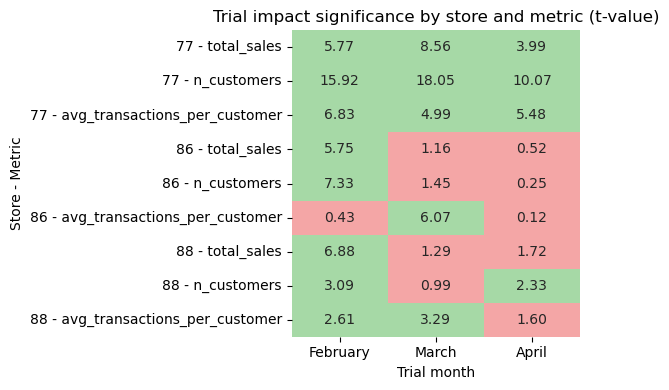

In [15]:
results_df_heatmap = results_df.copy()
results_df_heatmap['heatmap_label'] = (results_df_heatmap['trial'].astype(str) + ' - ' + results_df_heatmap['metric'])
results_df_heatmap = results_df_heatmap.set_index('heatmap_label')
results_df_heatmap = results_df_heatmap[['t_value_feb', 't_value_mar', 't_value_apr']]
results_df_heatmap.columns = ['February', 'March', 'April']


significance_mask = (results_df_heatmap >= t_critical).astype(int)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    data=significance_mask,
    annot=results_df_heatmap,
    fmt='.2f',
    cmap=ListedColormap(['#f4a6a6', '#a6d9a6']),
    cbar=False,
)
ax.set_title('Trial impact significance by store and metric (t-value)')
ax.set_xlabel('Trial month')
ax.set_ylabel('Store - Metric')
plt.tight_layout()
plt.show()


## 8. Visualizing results with confidence intervals

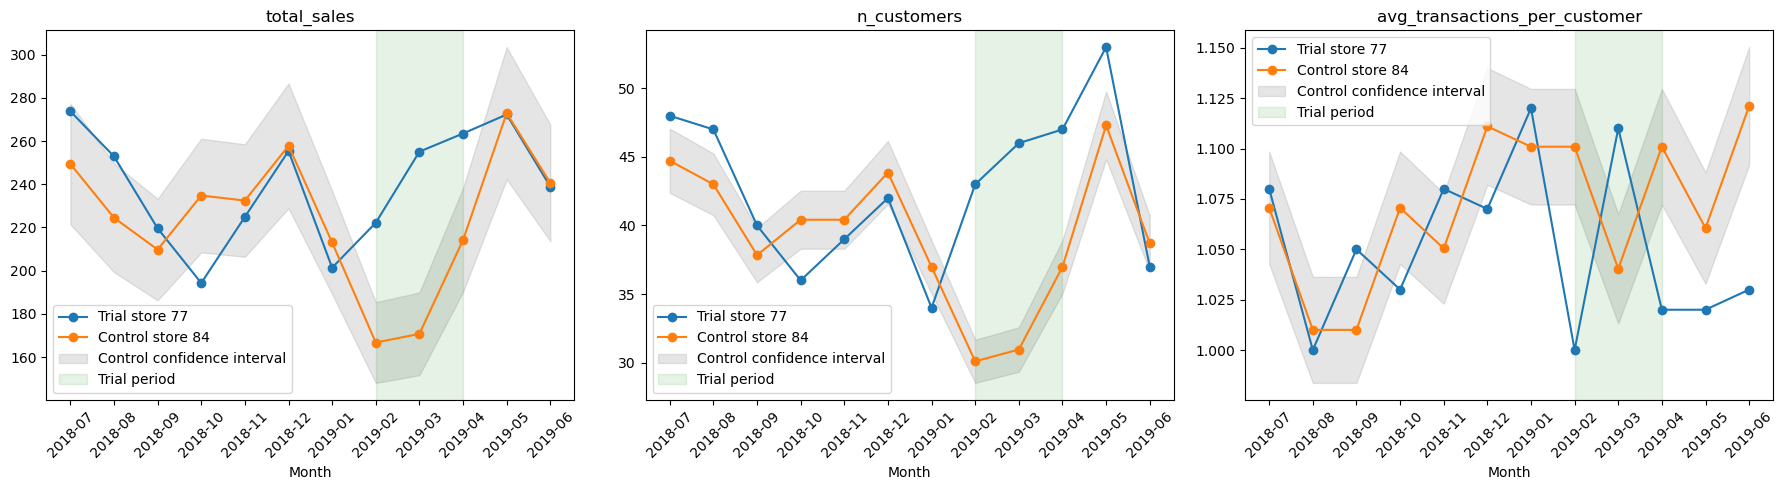

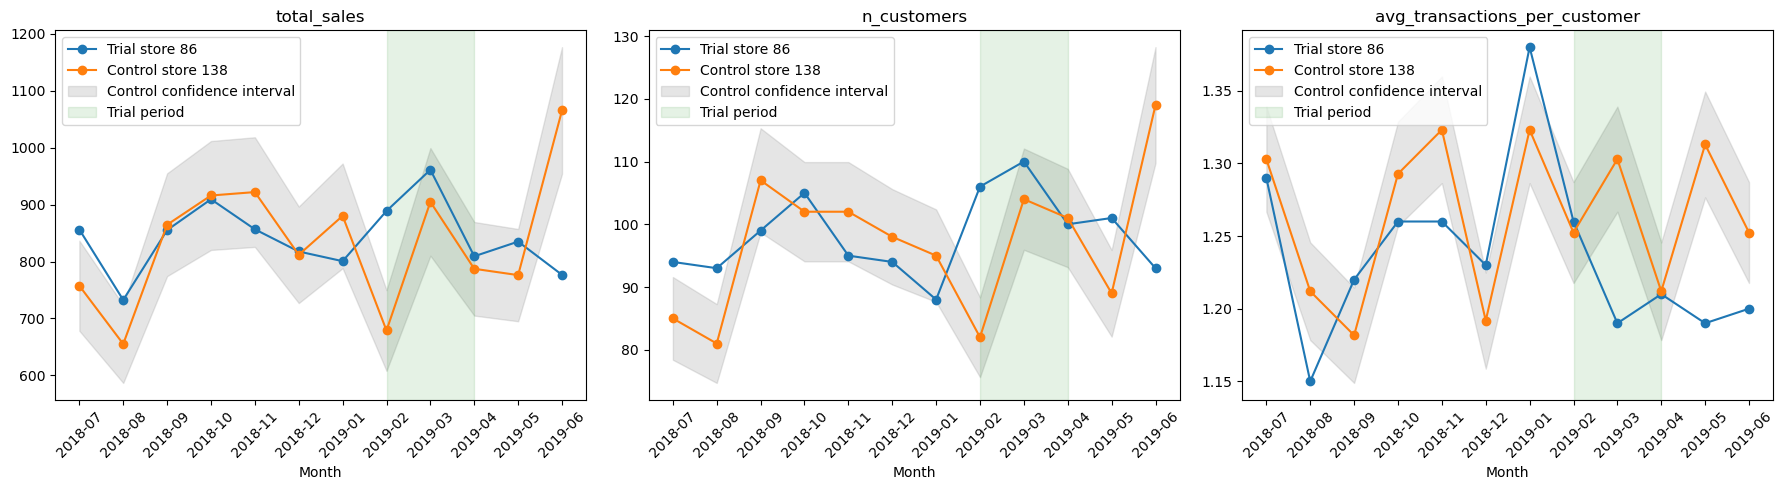

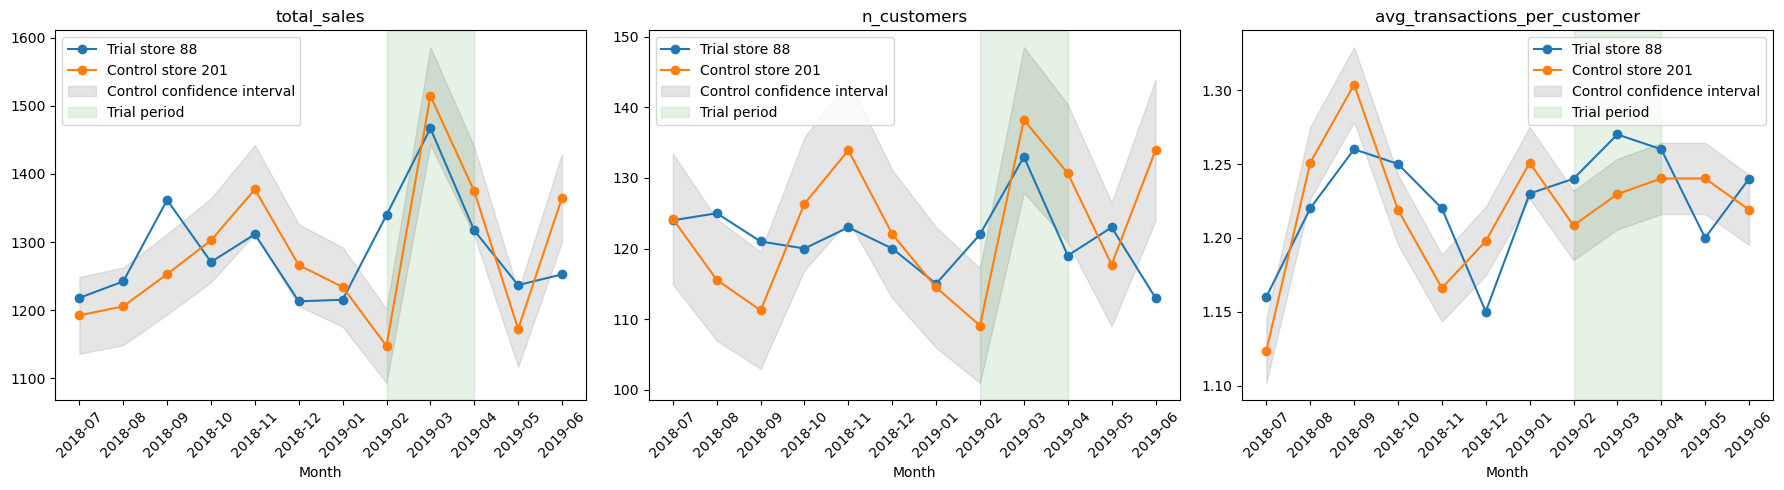

In [16]:
def plot_trial_vs_control_scaled(trial_store, control_store):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric in zip(axes, metrics):
        trial_data = monthly_stats.loc[trial_store, metric]
        scaling_factor = ((monthly_stats_before_trial[metric].loc[trial_store]).mean() / (monthly_stats_before_trial[metric].loc[control_store]).mean()).round(2)
        control_scaled = monthly_stats[metric].loc[control_store] * scaling_factor
        pct_diff = abs(control_scaled - trial_data) / control_scaled
        std_dev = pct_diff[pct_diff.index<'2019-02'].std()
        freedom = (monthly_stats_before_trial.index.get_level_values('MONTH').nunique()) - 1
        t_critical = stats.t.ppf(0.95, freedom)
        upper_band = control_scaled * (1 + t_critical * std_dev)
        lower_band = control_scaled * (1 - t_critical * std_dev)

        ax.plot(trial_data.index.astype(str), trial_data.values, marker='o', label=f'Trial store {trial_store}')
        ax.plot(control_scaled.index.astype(str), control_scaled.values, marker='o', label=f'Control store {control_store}')
        ax.fill_between(control_scaled.index.astype(str), upper_band, lower_band, color='grey', alpha=0.2, label='Control confidence interval')
        ax.axvspan('2019-02', '2019-04', color='green', alpha=0.1, label='Trial period')
        ax.set_title(metric)
        ax.set_xlabel('Month')
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

for trial_store, control_store in pairs.items():
    plot_trial_vs_control_scaled(trial_store, control_store)


## 9. Store-by-store analysis

Before evaluating the trial results, it's worth noting a limitation of the available data. Ideally, isolating the trial's effect from normal seasonal variation would call for comparing the trial period (February-April 2019) to the same calendar months the year before (February-April 2018), rather than to a different set of months. However, since the dataset only starts in July 2018, that year-over-year comparison isn't possible here. To account for this, the analysis instead relies on a control store, matched to the trial store's pre-trial performance (July 2018-January 2019), to estimate what the trial store's results would likely have looked like without the layout change. This helps control for factors other than the trial, but it does not fully rule out seasonal effects that a same-period, prior-year comparison would have captured.

It's also worth flagging a statistical caveat: this analysis runs nine significance tests in total (three trial stores × three metrics) at a 95% confidence level. Testing multiple hypotheses simultaneously increases the chance of at least one false positive by pure chance, beyond the nominal 5% per-test error rate. No correction for multiple comparisons (such as a Bonferroni adjustment) has been applied here, so individual significance results, especially those close to the threshold, should be interpreted with some caution.

### Store 77 (vs. control 84)

**Summary:** The trial produced a strong, statistically significant increase in total sales and customer traffic, sustained across the entire trial period, while purchase frequency swung significantly in both directions.

**Total sales:** remained significantly above the confidence band throughout the trial, with t-values of 5.77, 8.56, and 3.99 across February, March, and April respectively (against a 1.94 threshold), corresponding to gaps of 33%, 49%, and 23% above the scaled control.

**Customer count:** showed an even stronger effect, with t-values of 15.92, 18.05, and 10.07 over the same three months, translating into gaps of 43%, 49%, and 27%.

**Purchase frequency:** was significant in all three months as well, but the direction reversed repeatedly: roughly 9% below control in February, 7% above in March, then 7% below again in April, pointing to high volatility rather than a sustained shift.

**Interpretation:** Combined with the return to control-level sales and traffic shortly after the trial ended, these results suggest a strong short-term uplift in visits and revenue, likely amplified by a seasonally weak baseline period, without a lasting structural change in shopping behavior. Notably, since total_sales and n_customers returned to normal levels while avg_transactions_per_customer dropped well below control, each visit appears to have generated more revenue than usual, pointing to a possible increase in average basket size.

### Store 86 (vs. control 138)

**Summary:** The trial had no lasting significant impact on store 86: an initial spike in February faded quickly and did not translate into sustained performance gains.

**Total sales & customer count:** broke out of the control confidence interval only in February, the first trial month, with t-values of 5.75 and 7.33 respectively, both far above the 1.94 significance threshold, corresponding to gaps of roughly 31% and 29% above the scaled control. Both metrics fell back within the expected range for March and April (t-values between 0.25 and 1.45) and stayed there through the post-trial period, aside from a June outlier driven by a spike in the control store itself.

**Purchase frequency:** followed the opposite timing: it opened in line with the control store (t-value of 0.43 in February) before dropping roughly 8.7% below control in March (t-value of 6.07), then reverting to normal in April (t-value of 0.12).

**Interpretation:** The February spike in sales and traffic is best explained by a novelty effect, and its rapid fade over the following months, echoed by the delayed dip in purchase frequency, indicates the change did not produce a durable shift in customer behavior.

### Store 88 (vs. control 201)

**Summary:** The trial produced a mixed picture for store 88: a strong initial boost in sales and traffic in February that did not persist, alongside a modest but more consistent lift in purchase frequency during the first two trial months.

**Total sales:** broke out of the confidence interval only in February, with the trial store outperforming control by 16.7% (t-value of 6.88 against a 1.94 threshold), before returning to a level comparable to control for the rest of the trial.

**Customer count:** showed a similar early boost, up 11.8% above control in February (t-value of 3.09), but reversed by April, falling 8.9% below control (t-value of 2.33), suggesting the early traffic gain did not hold.

**Purchase frequency:** told a steadier story: it stayed significantly above control in both February and March (t-values of 2.61 and 3.29, gaps of roughly 3%), before converging with control in April.

**Interpretation:** Overall, the trial appears to have generated a short-lived spike in sales and visits rather than a lasting gain, while purchase frequency shows the closest signal to a small, sustained improvement.

## 10. Conclusion

Across all three trial stores, the layout change produced an immediate, statistically significant boost in sales and customer traffic during the first month of the trial, but its durability varied sharply from store to store, with only store 77 sustaining the effect through the full trial period.

All three stores recorded significant gaps above their control store in February: total_sales rose 33% for store 77, 31% for store 86, and 17% for store 88, with n_customers showing a similarly strong initial jump in each case. This consistent first-month pattern, observed independently across three unrelated control stores, makes a genuine short-term response to the new layout far more likely than a coincidence of pre-trial noise. From there, however, the stores diverge: store 77 kept outperforming its control on both sales and customer count through March and April, while stores 86 and 88 reverted to control-level performance almost immediately, with store 88's customer count even dipping below control by April. Purchase frequency (avg_transactions_per_customer) showed no consistent pattern across the three stores, alternating in store 77, dropping mid-trial in store 86, and rising modestly before flattening in store 88, so the trial's effect on this specific metric remains inconclusive.

Overall, the trial layout appears capable of driving a genuine, if often short-lived, uplift in traffic and sales, most likely reflecting a novelty effect in the majority of cases. Store 77 stands out as the one case where the effect held for the entire trial, which is worth investigating further with the Category Manager (for example, differences in execution, timing, or local store conditions) before deciding whether to roll out the layout more broadly. As noted earlier, the absence of same-period, prior-year data also means seasonal effects cannot be fully ruled out as a contributing factor, particularly for store 77's stronger and more sustained results.